# 🚀 AdaBoost & CatBoost — Combined Sales Forecasting Notebook

This notebook implements **two ensemble models** side-by-side for forecasting
`sales_amount_realistic` at the monthly store level:

| Model | Library | Base learner |
|-------|---------|-------------|
| **AdaBoost** | `sklearn` | `DecisionTreeRegressor` |
| **CatBoost** | `catboost` | Native gradient-boosted trees |

Both models share **identical feature engineering** (54 features) and are
evaluated on the same strict temporal hold-out set.  
Each model section includes its own **evaluation metrics, visualisations,
and a 12-month recursive forecast** (Jan 2025 → Dec 2025).

## 1 · Imports & Setup

In [1]:
import warnings, textwrap
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    r2_score, mean_absolute_percentage_error
)
from catboost import CatBoostRegressor

plt.rcParams.update({
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
})
sns.set_style('whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ All imports loaded successfully.')

✅ All imports loaded successfully.


## 2 · Data Loading

In [2]:
PROJECT_ROOT = Path.cwd().parent.resolve()
PROC = PROJECT_ROOT / 'data' / 'processed'

df_raw = pd.read_csv(PROC / 'cleaned_apple_sales_enriched_realistic.csv')
print(f'Raw dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Raw dataset: 1,040,200 rows × 35 columns


,sale_id,sale_date,store_id,product_id,quantity,product_name,launch_date,price,store_name,city,...,promo_factor,price_realistic,days_from_start,product_trend,trend_factor,store_factor,mu_demand,quantity_realistic,sales_amount_realistic,month
0,RW-18212,2020-01-01,ST-41,P-73,2,Apple One,2020-01-01,488,Apple Central World,Bangkok,...,1.0,471.375260,0,0.000783,1.0,1.219421,1.039677,3,1414.125780,1
1,RX-6848,2020-01-01,ST-31,P-40,7,iPhone SE (3rd Generation),2020-01-01,923,Apple Shinjuku,Tokyo,...,1.4,754.811217,0,0.000154,1.0,1.172288,10.813781,6,4528.867303,1
2,SV-39198,2020-01-01,ST-9,P-73,7,Apple One,2020-01-01,488,Apple Park Visitor Center,Cupertino,...,1.0,520.297395,0,0.000783,1.0,0.958735,6.406862,5,2601.486975,1


## 3 · Preprocessing — Monthly Store-Level Aggregation

We aggregate transaction-level data into monthly summaries per store.

In [3]:
df_raw['sale_date'] = pd.to_datetime(df_raw['sale_date'])
df_raw['year']  = df_raw['sale_date'].dt.year
df_raw['month'] = df_raw['sale_date'].dt.month

# Normalise country
if 'country_norm_mapped' not in df_raw.columns:
    df_raw['country_norm_mapped'] = df_raw['country'].str.lower().str.strip()

monthly_aggs = {
    'sales_amount_realistic': 'sum',
    'quantity_realistic': 'sum',
    'price_realistic': 'mean',
    'store_name': 'first',
    'country_norm_mapped': 'first',
    'num_transactions': 'sum' if 'num_transactions' in df_raw.columns else 'count',
}
if 'num_unique_products' in df_raw.columns:
    monthly_aggs['num_unique_products'] = 'max'
if 'promo_flag' in df_raw.columns:
    monthly_aggs['promo_flag'] = 'mean'
for ecol in ['gdp_per_capita','inflation_rate','exchange_rate','internet_usage_pct']:
    if ecol in df_raw.columns:
        monthly_aggs[ecol] = 'first'
if 'num_categories' in df_raw.columns:
    monthly_aggs['num_categories'] = 'max'

# Handle case where 'num_transactions' may not exist
if 'num_transactions' not in df_raw.columns:
    monthly_aggs.pop('num_transactions', None)

df_monthly = (
    df_raw.groupby(['store_id','year','month'])
    .agg(monthly_aggs)
    .reset_index()
)

# Create proper date
df_monthly['date'] = pd.to_datetime(
    df_monthly[['year','month']].assign(day=1))
df_monthly.sort_values(['store_id','date'], inplace=True)
df_monthly.reset_index(drop=True, inplace=True)

# Add num_transactions if missing
if 'num_transactions' not in df_monthly.columns:
    df_monthly['num_transactions'] = (
        df_raw.groupby(['store_id','year','month']).size().values
    )

# Add num_unique_products if missing
if 'num_unique_products' not in df_monthly.columns:
    df_monthly['num_unique_products'] = (
        df_raw.groupby(['store_id','year','month'])['product_id']
        .nunique().values
    )
# 👇 THIS IS THE NEW PART I ADDED 👇
# Add num_categories if missing
if 'num_categories' not in df_monthly.columns and 'category_id' in df_raw.columns:
    df_monthly['num_categories'] = (
        df_raw.groupby(['store_id','year','month'])['category_id']
        .nunique().values
    )
# 👆👆👆👆👆👆👆👆👆👆👆👆👆👆👆👆👆👆👆👆👆
print(f'Monthly dataset: {df_monthly.shape[0]:,} rows × {df_monthly.shape[1]} columns')
print(f"Date range: {df_monthly['date'].min().date()} → {df_monthly['date'].max().date()}")
df_monthly.head(5)

Monthly dataset: 4,425 rows × 17 columns
Date range: 2020-01-01 → 2024-11-01


,store_id,year,month,sales_amount_realistic,quantity_realistic,price_realistic,store_name,country_norm_mapped,promo_flag,gdp_per_capita,inflation_rate,exchange_rate,internet_usage_pct,date,num_transactions,num_unique_products,num_categories
0,ST-1,2020,1,1.469554e+06,1513,1058.958272,Apple Fifth Avenue,united states,0.100000,64401.50744,1.233584,1.0,90.3447,2020-01-01,270,83,10
1,ST-1,2020,2,1.767766e+06,1650,1097.185587,Apple Fifth Avenue,united states,0.099174,64401.50744,1.233584,1.0,90.3447,2020-02-01,242,84,10
2,ST-1,2020,3,1.763047e+06,1674,1067.870490,Apple Fifth Avenue,united states,0.058140,64401.50744,1.233584,1.0,90.3447,2020-03-01,258,83,10
3,ST-1,2020,4,1.809825e+06,1702,1057.462308,Apple Fifth Avenue,united states,0.114894,64401.50744,1.233584,1.0,90.3447,2020-04-01,235,82,10
4,ST-1,2020,5,1.836877e+06,1802,1071.183457,Apple Fifth Avenue,united states,0.096639,64401.50744,1.233584,1.0,90.3447,2020-05-01,238,79,10


## 4 · Feature Engineering

54 features across six categories: lags, rolling statistics, trend/momentum,
cyclical time, economic indicators, and store/category encodings.

In [4]:
TARGET = 'sales_amount_realistic'
LAG_MONTHS = [1, 2, 3, 4, 5, 6]
WINDOWS    = [3, 6, 12]

# ── lag features ──
for lag in LAG_MONTHS:
    df_monthly[f'sales_lag_{lag}'] = df_monthly.groupby('store_id')[TARGET].shift(lag)
    df_monthly[f'qty_lag_{lag}']   = df_monthly.groupby('store_id')['quantity_realistic'].shift(lag)
df_monthly['sales_lag_12'] = df_monthly.groupby('store_id')[TARGET].shift(12)
df_monthly['qty_lag_12']   = df_monthly.groupby('store_id')['quantity_realistic'].shift(12)

# ── rolling statistics ──
for w in WINDOWS:
    rolled_sales = df_monthly.groupby('store_id')[TARGET].shift(1).rolling(w, min_periods=1)
    df_monthly[f'sales_roll_mean_{w}'] = rolled_sales.mean().reset_index(0, drop=True)
    df_monthly[f'sales_roll_std_{w}']  = rolled_sales.std().reset_index(0, drop=True)
    df_monthly[f'sales_roll_min_{w}']  = rolled_sales.min().reset_index(0, drop=True)
    df_monthly[f'sales_roll_max_{w}']  = rolled_sales.max().reset_index(0, drop=True)
for w in [3, 6]:
    rolled_qty = df_monthly.groupby('store_id')['quantity_realistic'].shift(1).rolling(w, min_periods=1)
    df_monthly[f'qty_roll_mean_{w}'] = rolled_qty.mean().reset_index(0, drop=True)

# ── trend / momentum ──
df_monthly['sales_mom_pct'] = df_monthly.groupby('store_id')[TARGET].pct_change()
df_monthly['sales_expanding_mean'] = (
    df_monthly.groupby('store_id')[TARGET]
    .transform(lambda s: s.shift(1).expanding().mean())
)
df_monthly['sales_lag1_vs_roll6'] = (
    df_monthly['sales_lag_1'] / df_monthly['sales_roll_mean_6'].replace(0, np.nan)
)

# ── cyclical time ──
df_monthly['month_sin']   = np.sin(2 * np.pi * df_monthly['month'] / 12)
df_monthly['month_cos']   = np.cos(2 * np.pi * df_monthly['month'] / 12)
q = (df_monthly['month'] - 1) // 3 + 1
df_monthly['quarter_sin'] = np.sin(2 * np.pi * q / 4)
df_monthly['quarter_cos'] = np.cos(2 * np.pi * q / 4)
df_monthly['is_holiday_season'] = df_monthly['month'].isin([11, 12]).astype(int)
df_monthly['is_launch_season']  = df_monthly['month'].isin([9, 10]).astype(int)

# ── economic deltas ──
for col in ['gdp_per_capita','inflation_rate','exchange_rate','internet_usage_pct']:
    if col in df_monthly.columns:
        df_monthly[col.replace('_per_capita','').replace('_rate','').replace('_pct','') + '_change'] = (
            df_monthly.groupby('store_id')[col].pct_change().fillna(0)
        )

# ── store / country encoding ──
for enc_col in ['store_id', 'country_norm_mapped']:
    le = LabelEncoder()
    df_monthly[enc_col.replace('_norm_mapped','').replace('_id','') + '_encoded'] = (
        le.fit_transform(df_monthly[enc_col]))

store_means = df_monthly.groupby('store_id')[TARGET].transform('mean')
df_monthly['store_target_enc'] = store_means

print(f'Features engineered ✅  — {df_monthly.shape[1]} total columns')

Features engineered ✅  — 61 total columns


## 5 · Data Cleaning (Remove Lag NaNs)

In [5]:
# Drop first 6 months per store (NaN from lags)
df_monthly['row_num'] = df_monthly.groupby('store_id').cumcount()
df_clean = df_monthly[df_monthly['row_num'] >= 6].copy()
df_clean.drop(columns='row_num', inplace=True)
df_monthly.drop(columns='row_num', inplace=True)

numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(0)

print(f'After cleanup: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns')
print(f'Remaining NaNs: {df_clean.isnull().sum().sum()}')

After cleanup: 3,975 rows × 61 columns
Remaining NaNs: 0


## 6 · Feature Selection & Train / Test Split

In [6]:
FEATURES = [
    'sales_lag_1','sales_lag_2','sales_lag_3',
    'sales_lag_4','sales_lag_5','sales_lag_6','sales_lag_12',
    'qty_lag_1','qty_lag_2','qty_lag_3',
    'qty_lag_4','qty_lag_5','qty_lag_6','qty_lag_12',
    'sales_roll_mean_3','sales_roll_std_3','sales_roll_min_3','sales_roll_max_3',
    'sales_roll_mean_6','sales_roll_std_6','sales_roll_min_6','sales_roll_max_6',
    'sales_roll_mean_12','sales_roll_std_12','sales_roll_min_12','sales_roll_max_12',
    'qty_roll_mean_3','qty_roll_mean_6',
    'sales_mom_pct','sales_expanding_mean','sales_lag1_vs_roll6',
    'price_realistic','promo_flag',
    'month_sin','month_cos','quarter_sin','quarter_cos','year',
    'is_holiday_season','is_launch_season',
    'gdp_per_capita','inflation_rate','exchange_rate','internet_usage_pct',
    'gdp_change','inflation_change','exchange_change','internet_usage_change',
    'store_encoded','country_encoded','store_target_enc',
    'num_transactions','num_unique_products','num_categories',
]

# Verify
missing = [f for f in FEATURES if f not in df_clean.columns]
if missing:
    print(f'⚠️  Missing: {missing}')
    FEATURES = [f for f in FEATURES if f in df_clean.columns]
print(f'✅ Using {len(FEATURES)} features.')

# Temporal split
CUTOFF_DATE = df_clean['date'].max() - pd.DateOffset(months=5)
train_mask = df_clean['date'] < CUTOFF_DATE
test_mask  = df_clean['date'] >= CUTOFF_DATE

X_train = df_clean.loc[train_mask, FEATURES]
y_train = df_clean.loc[train_mask, TARGET]
X_test  = df_clean.loc[test_mask,  FEATURES]
y_test  = df_clean.loc[test_mask,  TARGET]
test_data = df_clean.loc[test_mask].copy()

print(f'Train : {X_train.shape[0]:,} rows  |  Test : {X_test.shape[0]:,} rows')
print(f'Train period: < {CUTOFF_DATE.date()}')
print(f'Test  period: {CUTOFF_DATE.date()} → {df_clean["date"].max().date()}')

✅ Using 54 features.
Train : 3,525 rows  |  Test : 450 rows
Train period: < 2024-06-01
Test  period: 2024-06-01 → 2024-11-01


## 7 · Shared Helper Functions

In [7]:
def evaluate_model(model, X_test, y_test, test_data, model_name):
    """Compute metrics and return predictions."""
    y_pred = model.predict(X_test)
    test_data = test_data.copy()
    test_data['y_pred'] = y_pred

    metrics = {
        'Model': model_name,
        'MAE':  mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred) * 100,
        'R²':   r2_score(y_test, y_pred),
    }
    print(f'\n─── {model_name} — Test Metrics ───')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'  {k:5s} = {v:,.2f}' if k != 'R²' else f'  {k:5s} = {v:.4f}')
    return y_pred, test_data, metrics


def plot_model_results(model, X_test, y_test, y_pred, test_data,
                       model_name, feature_names):
    """Six-panel visualisation suite for a single model."""

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'{model_name} — Evaluation Dashboard', fontsize=18, fontweight='bold', y=1.02)

    # 1 — Feature importance (top 15)
    ax = axes[0, 0]
    if hasattr(model, 'feature_importances_'):
        imp = pd.Series(model.feature_importances_, index=feature_names)
    else:
        imp = pd.Series(np.zeros(len(feature_names)), index=feature_names)
    imp.nlargest(15).sort_values().plot.barh(ax=ax, color=sns.color_palette('viridis', 15))
    ax.set_title('Top 15 Feature Importances')

    # 2 — Actual vs Predicted scatter
    ax = axes[0, 1]
    ax.scatter(y_test, y_pred, alpha=0.35, s=20, color='#2196F3')
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    ax.plot([mn, mx], [mn, mx], 'r--', lw=1.5)
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    ax.set_title('Actual vs Predicted (Test)')

    # 3 — Residual distribution
    ax = axes[0, 2]
    residuals = y_test.values - y_pred
    ax.hist(residuals, bins=40, color='coral', edgecolor='white')
    ax.axvline(0, color='black', linestyle='--')
    ax.set_title('Residual Distribution'); ax.set_xlabel('Residual')

    # 4 — Aggregated time-series
    ax = axes[1, 0]
    agg = test_data.groupby('date').agg(actual=(TARGET,'sum'), predicted=('y_pred','sum')).reset_index()
    ax.plot(agg['date'], agg['actual'], 'o-', label='Actual', color='#2196F3')
    ax.plot(agg['date'], agg['predicted'], 's--', label='Predicted', color='#FF5722')
    ax.fill_between(agg['date'], agg['actual'], agg['predicted'], alpha=0.15, color='gray')
    ax.set_title('Aggregated Monthly Sales — Actual vs Predicted')
    ax.legend()

    # 5 & 6 — Per-store MAE / R² distributions
    store_metrics = test_data.groupby('store_id').apply(
        lambda g: pd.Series({
            'MAE': mean_absolute_error(g[TARGET], g['y_pred']),
            'R2':  r2_score(g[TARGET], g['y_pred']) if len(g) > 1 else np.nan,
        })
    ).reset_index()
    store_metrics['MAE'] = store_metrics['MAE'].astype(float)
    store_metrics['R2']  = store_metrics['R2'].astype(float)

    axes[1, 1].hist(store_metrics['MAE'], bins=25, color='steelblue', edgecolor='white')
    axes[1, 1].set_title('Per-Store MAE Distribution'); axes[1, 1].set_xlabel('MAE')
    axes[1, 2].hist(store_metrics['R2'].dropna(), bins=25, color='coral', edgecolor='white')
    axes[1, 2].axvline(0, color='gray', linestyle='--')
    axes[1, 2].set_title('Per-Store R² Distribution'); axes[1, 2].set_xlabel('R²')

    plt.tight_layout()
    plt.show()


def forecast_one_year(model, df_clean, feature_names, model_name):
    """12-month recursive forecast (Jan–Dec 2025) for every store."""
    stores = df_clean['store_id'].unique()
    all_forecasts = []

    for store in stores:
        store_hist = df_clean[df_clean['store_id'] == store].sort_values('date').tail(12).copy()
        store_name = store_hist['store_name'].iloc[0]
        country    = store_hist['country_norm_mapped'].iloc[0]

        recent_sales = store_hist['sales_amount_realistic'].tolist()
        recent_qty   = store_hist['quantity_realistic'].tolist()

        for forecast_month_offset in range(1, 13):
            base_date = store_hist['date'].max()
            fdate = base_date + pd.DateOffset(months=forecast_month_offset)
            m, y = fdate.month, fdate.year

            row = {}
            # Lags
            for lag in LAG_MONTHS:
                row[f'sales_lag_{lag}'] = recent_sales[-lag] if lag <= len(recent_sales) else 0
                row[f'qty_lag_{lag}']   = recent_qty[-lag]   if lag <= len(recent_qty)   else 0
            row['sales_lag_12'] = recent_sales[-12] if len(recent_sales) >= 12 else 0
            row['qty_lag_12']   = recent_qty[-12]   if len(recent_qty)   >= 12 else 0

            # Rolling stats
            for w in WINDOWS:
                window = recent_sales[-w:] if len(recent_sales) >= w else recent_sales
                row[f'sales_roll_mean_{w}'] = np.mean(window)
                row[f'sales_roll_std_{w}']  = np.std(window) if len(window) > 1 else 0
                row[f'sales_roll_min_{w}']  = np.min(window)
                row[f'sales_roll_max_{w}']  = np.max(window)
            for w in [3, 6]:
                window = recent_qty[-w:] if len(recent_qty) >= w else recent_qty
                row[f'qty_roll_mean_{w}'] = np.mean(window)

            # Trend / momentum
            row['sales_mom_pct'] = (recent_sales[-1] - recent_sales[-2]) / max(recent_sales[-2], 1) if len(recent_sales) >= 2 else 0
            row['sales_expanding_mean'] = np.mean(recent_sales)
            roll6_mean = np.mean(recent_sales[-6:]) if len(recent_sales) >= 6 else np.mean(recent_sales)
            row['sales_lag1_vs_roll6'] = recent_sales[-1] / max(roll6_mean, 1)

            # Price & promo — carry forward
            row['price_realistic'] = store_hist['price_realistic'].iloc[-1]
            row['promo_flag']      = store_hist['promo_flag'].iloc[-1]

            # Time / seasonal
            row['month_sin'] = np.sin(2 * np.pi * m / 12)
            row['month_cos'] = np.cos(2 * np.pi * m / 12)
            qq = (m - 1) // 3 + 1
            row['quarter_sin'] = np.sin(2 * np.pi * qq / 4)
            row['quarter_cos'] = np.cos(2 * np.pi * qq / 4)
            row['year'] = y
            row['is_holiday_season'] = 1 if m in [11, 12] else 0
            row['is_launch_season']  = 1 if m in [9, 10]  else 0

            # Economic — carry forward
            for col in ['gdp_per_capita','inflation_rate','exchange_rate','internet_usage_pct']:
                if col in store_hist.columns:
                    row[col] = store_hist[col].iloc[-1]
            for col in ['gdp_change','inflation_change','exchange_change','internet_usage_change']:
                if col in store_hist.columns:
                    row[col] = store_hist[col].iloc[-1]
                else:
                    row[col] = 0

            # Store / categorical
            for col in ['store_encoded','country_encoded','store_target_enc',
                        'num_transactions','num_unique_products','num_categories']:
                if col in store_hist.columns:
                    row[col] = store_hist[col].iloc[-1]

            # ── predict ──
            X_future = pd.DataFrame([row])
            # ensure only known features
            for f in feature_names:
                if f not in X_future.columns:
                    X_future[f] = 0
            X_future = X_future[feature_names]
            pred_sales = max(model.predict(X_future)[0], 0)

            all_forecasts.append({
                'store_id': store, 'store_name': store_name,
                'country': country, 'date': fdate,
                'predicted_sales': pred_sales,
            })

            # ── update history for next step ──
            recent_sales.append(pred_sales)
            recent_qty.append(int(store_hist['quantity_realistic'].iloc[-1]))  # carry forward

    forecast_df = pd.DataFrame(all_forecasts)
    forecast_df['date'] = pd.to_datetime(forecast_df['date'])
    print(f'\n✅ {model_name}: Generated {len(forecast_df):,} forecasts '
          f'({len(stores)} stores × 12 months)')
    print(f'   Total predicted sales: {forecast_df["predicted_sales"].sum():,.2f}')
    return forecast_df


def plot_historical_and_forecast(forecast_df, df_clean, model_name):
    """Historical total monthly sales line + 12-month forecast continuation."""
    # Historical aggregated monthly total
    hist = df_clean.groupby('date')[TARGET].sum().reset_index()
    hist.columns = ['date', 'sales']
    hist['type'] = 'Historical'

    # Forecast aggregated monthly total
    fc = forecast_df.groupby('date')['predicted_sales'].sum().reset_index()
    fc.columns = ['date', 'sales']
    fc['type'] = 'Forecast'

    fig, ax = plt.subplots(figsize=(18, 6))

    ax.plot(hist['date'], hist['sales'], 'o-', color='#2196F3',
            label='Historical (Actual)', linewidth=2, markersize=4)
    ax.plot(fc['date'], fc['sales'], 's--', color='#FF5722',
            label=f'{model_name} Forecast', linewidth=2, markersize=6)

    # Connect last historical point to first forecast point
    ax.plot([hist['date'].iloc[-1], fc['date'].iloc[0]],
            [hist['sales'].iloc[-1], fc['sales'].iloc[0]],
            '--', color='gray', linewidth=1.5, alpha=0.6)

    # Shade forecast region
    ax.axvspan(fc['date'].iloc[0], fc['date'].iloc[-1], alpha=0.08, color='orange',
               label='Forecast Period')

    # Annotate forecast values
    for _, r in fc.iterrows():
        ax.annotate(f'{r["sales"]/1e6:.1f}M',
                    xy=(r['date'], r['sales']),
                    textcoords='offset points', xytext=(0, 12),
                    ha='center', fontsize=8, fontweight='bold', color='#FF5722')

    ax.set_title(f'{model_name} — Total Monthly Sales: Historical + 2025 Forecast',
                 fontsize=16, fontweight='bold')
    ax.set_xlabel('Date'); ax.set_ylabel('Total Sales')
    ax.legend(fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    plt.show()


def plot_forecast(forecast_df, model_name):
    """Visualise the 12-month forecast with value labels."""
    monthly_total = forecast_df.groupby('date')['predicted_sales'].sum().reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(20, 7))
    fig.suptitle(f'{model_name} — 12-Month Forecast (Jan–Dec 2025)',
                 fontsize=16, fontweight='bold')

    # ── Left: monthly totals with value labels ──
    ax = axes[0]
    colors = sns.color_palette('viridis', 12)
    bars = ax.bar(monthly_total['date'].dt.strftime('%Y-%m'),
                  monthly_total['predicted_sales'], color=colors)
    # Add value on top of each bar
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., h,
                f'{h/1e6:.1f}M', ha='center', va='bottom',
                fontsize=9, fontweight='bold')
    ax.set_title('Total Predicted Sales by Month')
    ax.set_ylabel('Total Sales')
    ax.tick_params(axis='x', rotation=45)

    # ── Right: top 10 stores with value labels ──
    top_stores = (forecast_df.groupby('store_name')['predicted_sales']
                  .sum().nlargest(10).sort_values())
    ax = axes[1]
    bars_h = top_stores.plot.barh(ax=ax, color=sns.color_palette('magma', 10))
    for i, (val, name) in enumerate(zip(top_stores.values, top_stores.index)):
        ax.text(val, i, f' {val/1e6:.2f}M', va='center', fontsize=9, fontweight='bold')
    ax.set_title('Top 10 Stores — Total Predicted Sales (12 months)')
    ax.set_xlabel('Predicted Sales')

    plt.tight_layout()
    plt.show()

    # Show sample table
    display(forecast_df.head(12))


def plot_top_bottom_stores(forecast_df, model_name, n=5):
    """Line charts for top-N and bottom-N stores month-by-month."""
    store_totals = forecast_df.groupby('store_name')['predicted_sales'].sum()
    top_names    = store_totals.nlargest(n).index.tolist()
    bottom_names = store_totals.nsmallest(n).index.tolist()

    fig, axes = plt.subplots(1, 2, figsize=(22, 7))
    fig.suptitle(f'{model_name} — Top {n} vs Bottom {n} Stores (Monthly Forecast 2025)',
                 fontsize=16, fontweight='bold')

    # Top N
    ax = axes[0]
    for name in top_names:
        sdf = forecast_df[forecast_df['store_name'] == name].sort_values('date')
        ax.plot(sdf['date'], sdf['predicted_sales'], 'o-', label=name, linewidth=2, markersize=5)
    ax.set_title(f'Top {n} Stores')
    ax.set_xlabel('Month'); ax.set_ylabel('Predicted Sales')
    ax.legend(fontsize=8, loc='best')
    ax.tick_params(axis='x', rotation=30)

    # Bottom N
    ax = axes[1]
    for name in bottom_names:
        sdf = forecast_df[forecast_df['store_name'] == name].sort_values('date')
        ax.plot(sdf['date'], sdf['predicted_sales'], 'o-', label=name, linewidth=2, markersize=5)
    ax.set_title(f'Bottom {n} Stores')
    ax.set_xlabel('Month'); ax.set_ylabel('Predicted Sales')
    ax.legend(fontsize=8, loc='best')
    ax.tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()


def plot_baseline_vs_tuned_top5(baseline_test, tuned_test, model_name):
    """Compare Baseline vs Tuned model predictions against Actual for top 5 stores."""
    # Identify top 5 stores by actual total sales in test set
    store_totals = tuned_test.groupby('store_name')[TARGET].sum()
    top5 = store_totals.nlargest(5).index.tolist()

    fig, axes = plt.subplots(2, 3, figsize=(22, 12))
    fig.suptitle(f'{model_name} — Baseline vs Tuned vs Actual (Top 5 Stores)',
                 fontsize=16, fontweight='bold', y=1.02)

    for idx, store_name in enumerate(top5):
        row, col = divmod(idx, 3)
        ax = axes[row, col]

        b = baseline_test[baseline_test['store_name'] == store_name].sort_values('date')
        t = tuned_test[tuned_test['store_name'] == store_name].sort_values('date')

        ax.plot(t['date'], t[TARGET], 'o-', label='Actual', color='#4CAF50', linewidth=2)
        ax.plot(b['date'], b['y_pred'], 's--', label='Baseline', color='#9E9E9E', linewidth=1.5)
        ax.plot(t['date'], t['y_pred'], '^--', label='Tuned', color='#FF5722', linewidth=2)

        ax.set_title(store_name, fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=30)

    # Hide last subplot if only 5
    axes[1, 2].set_visible(False)
    plt.tight_layout()
    plt.show()

---
# Part A — AdaBoost Regressor
---

## A1 · Baseline AdaBoost (Default Parameters)

In [8]:
tscv = TimeSeriesSplit(n_splits=5)

ada_baseline = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=3),
    n_estimators=50,
    learning_rate=0.1,
    loss='linear',
    random_state=RANDOM_STATE,
)
ada_baseline.fit(X_train, y_train)

ada_base_pred, ada_base_test, ada_base_metrics = evaluate_model(
    ada_baseline, X_test, y_test, test_data, 'AdaBoost (Baseline)')


─── AdaBoost (Baseline) — Test Metrics ───
  MAE   = 293,944.27
  RMSE  = 499,496.47
  MAPE  = 27.41
  R²    = 0.5173


## A2 · Hyperparameter Tuning (GridSearchCV + TimeSeriesSplit)

In [9]:
%%time

ada_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5],
    'estimator__max_depth': [3, 6, 10],
}

ada_search = GridSearchCV(
    estimator=AdaBoostRegressor(
        estimator=DecisionTreeRegressor(),
        loss='linear',
        random_state=RANDOM_STATE,
    ),
    param_grid=ada_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
)

ada_search.fit(X_train, y_train)
print(f'\n✅ Best parameters: {ada_search.best_params_}')
print(f'   Best CV MAE:    {-ada_search.best_score_:,.2f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ Best parameters: {'estimator__max_depth': 10, 'learning_rate': 0.5, 'n_estimators': 200}
   Best CV MAE:    76,885.90
CPU times: total: 13.5 s
Wall time: 1min 22s


## A3 · Tuned AdaBoost — Evaluation on Test Set

In [10]:
ada_best = ada_search.best_estimator_
ada_pred, ada_test, ada_metrics = evaluate_model(
    ada_best, X_test, y_test, test_data, 'AdaBoost (Tuned)')


─── AdaBoost (Tuned) — Test Metrics ───
  MAE   = 178,066.91
  RMSE  = 391,839.30
  MAPE  = 19.44
  R²    = 0.7029


## A4 · AdaBoost Visualisations

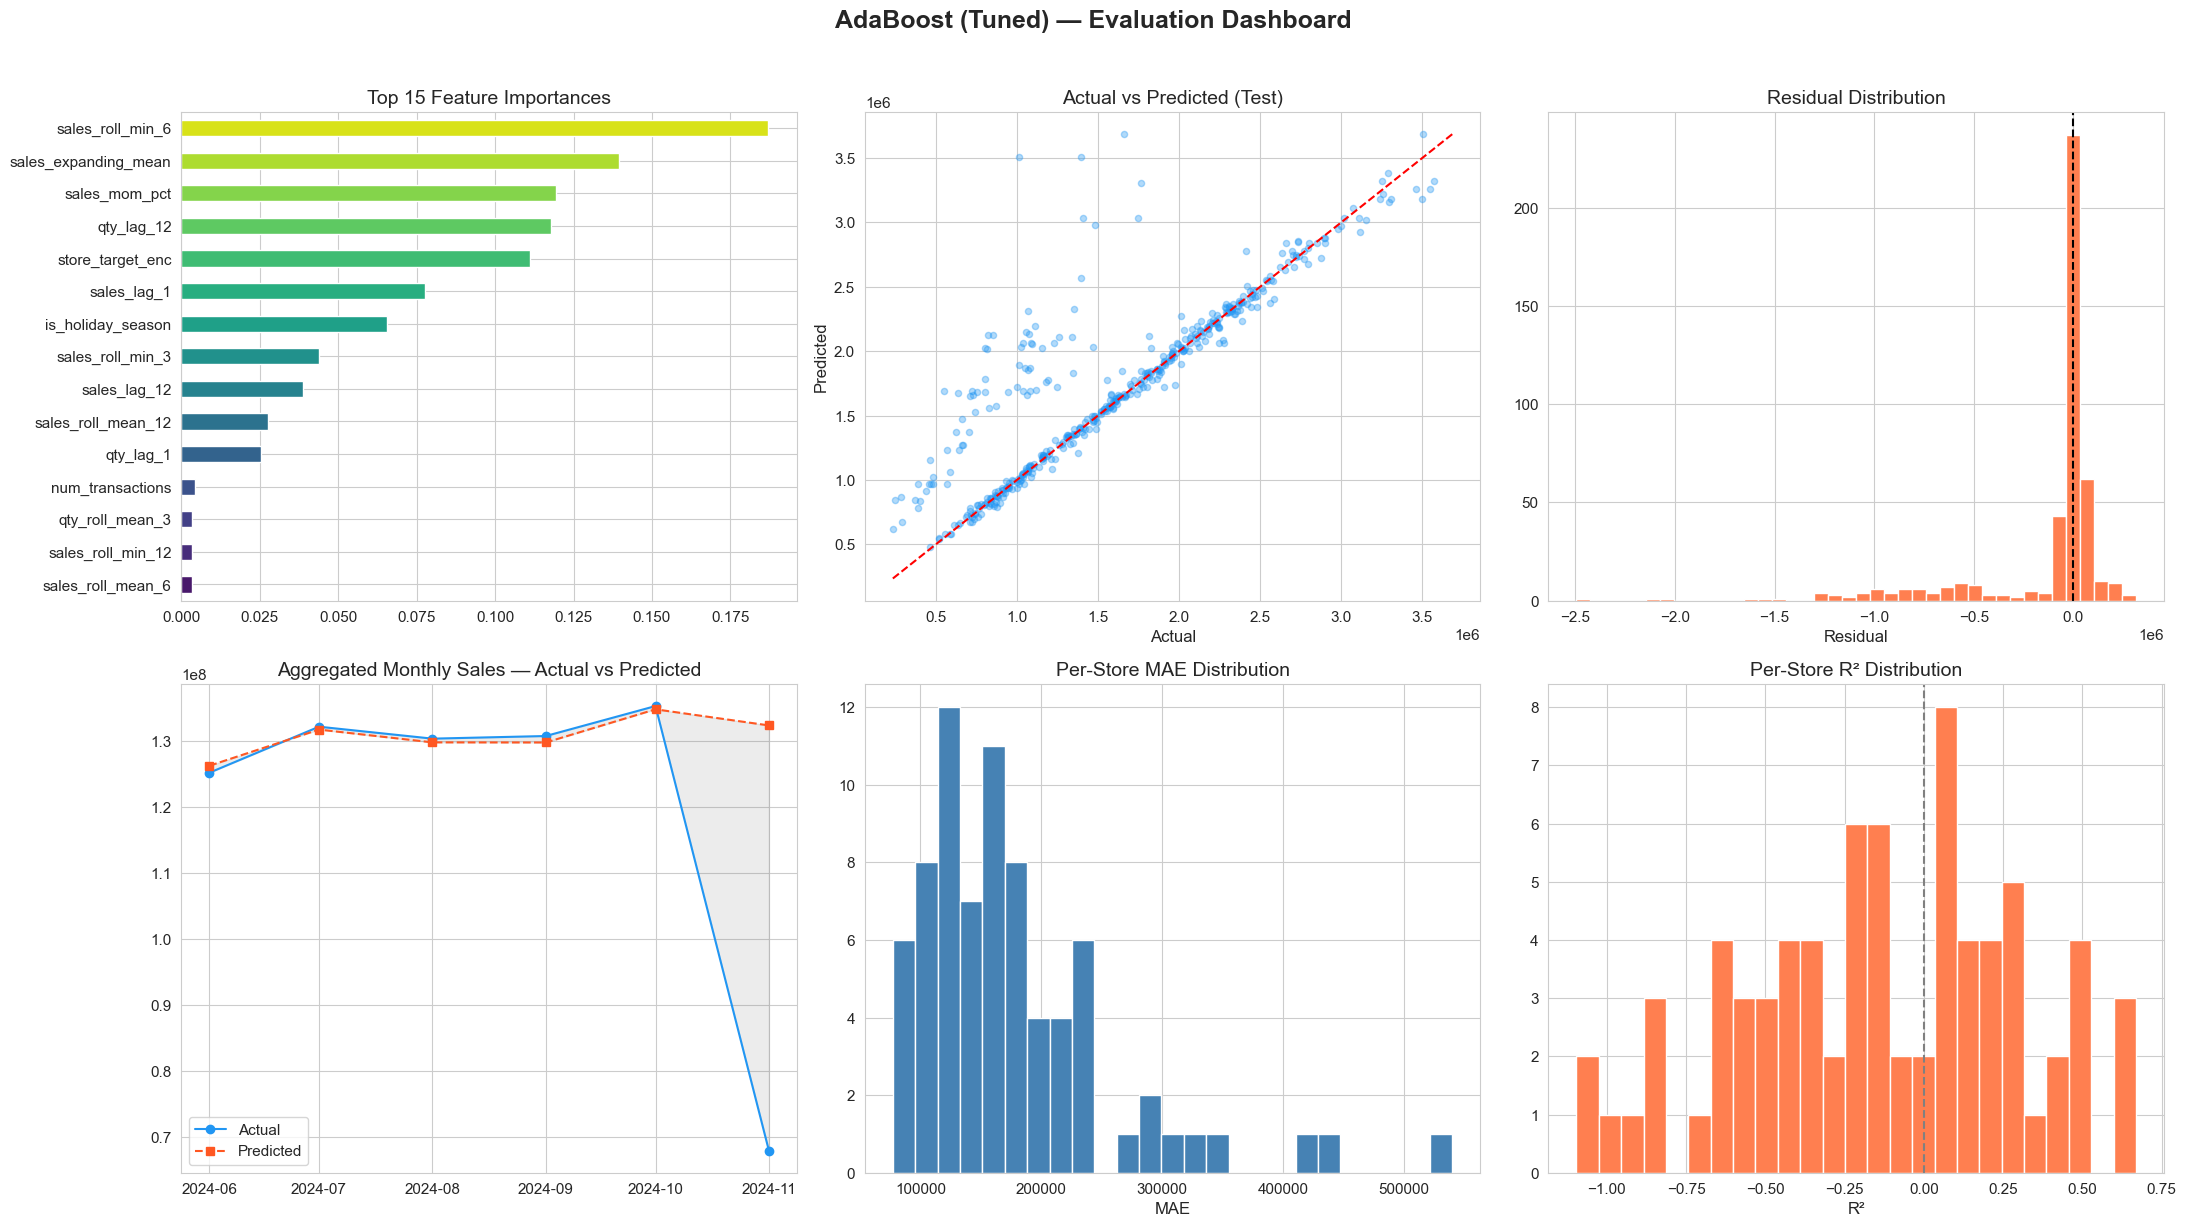

In [11]:
plot_model_results(ada_best, X_test, y_test, ada_pred, ada_test,
                   'AdaBoost (Tuned)', FEATURES)

## A5 · Baseline vs Tuned — Top 5 Stores (AdaBoost)

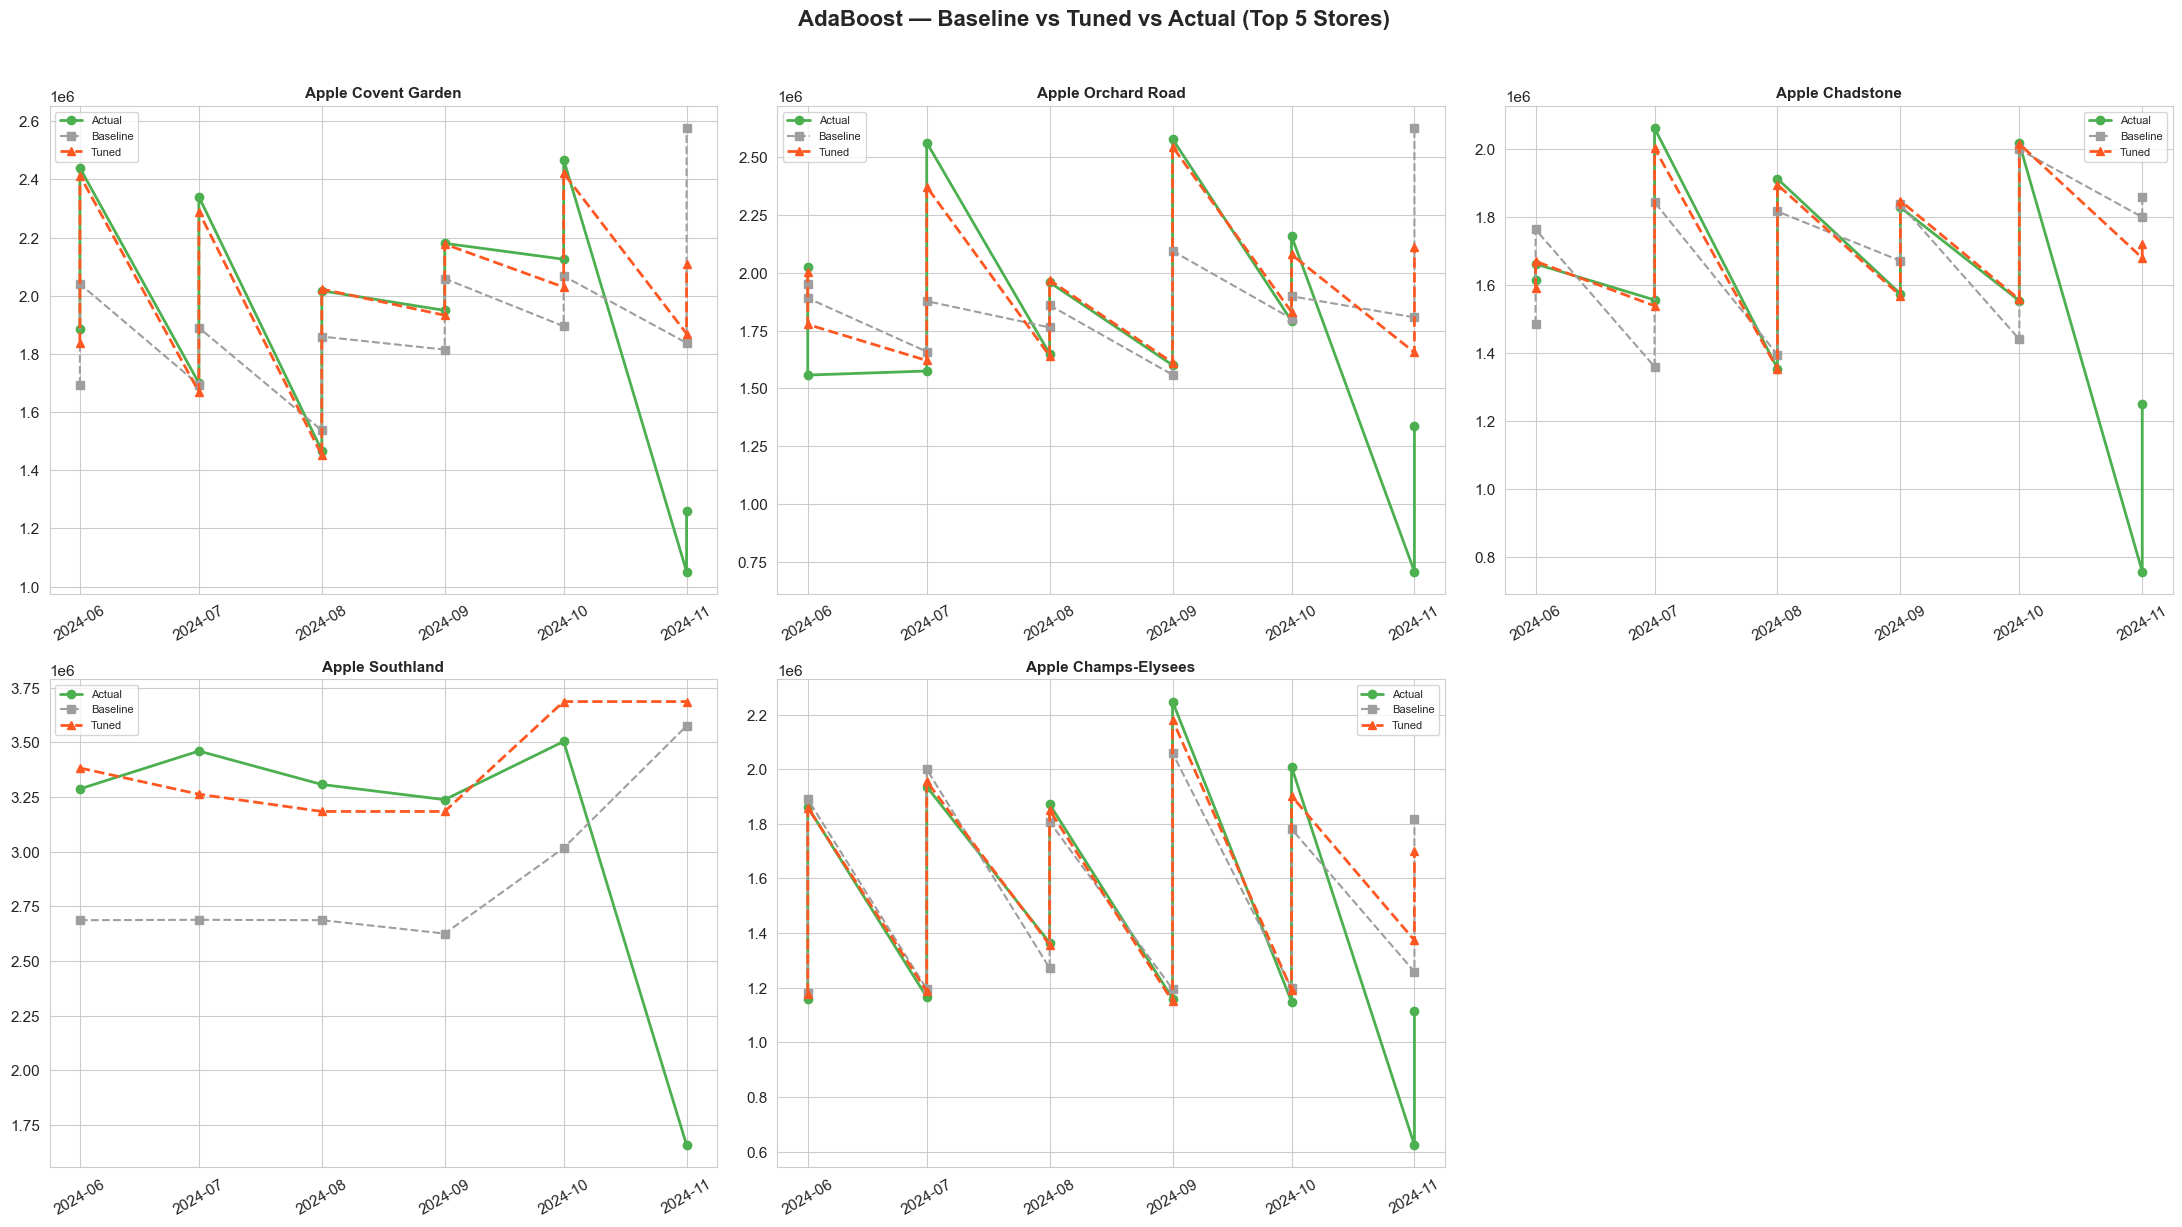

In [12]:
plot_baseline_vs_tuned_top5(ada_base_test, ada_test, 'AdaBoost')

## A6 · AdaBoost — 12-Month Forecast (Jan–Dec 2025)

In [13]:
# Retrain on ALL data for the best possible forecast
X_all = df_clean[FEATURES]
y_all = df_clean[TARGET]

ada_final = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(
        max_depth=ada_search.best_params_.get('estimator__max_depth', 6)),
    n_estimators=ada_search.best_params_.get('n_estimators', 200),
    learning_rate=ada_search.best_params_.get('learning_rate', 0.1),
    loss='linear',
    random_state=RANDOM_STATE,
)
ada_final.fit(X_all, y_all)
print('✅ AdaBoost final model retrained on all data.')

ada_forecast = forecast_one_year(ada_final, df_clean, FEATURES, 'AdaBoost')

✅ AdaBoost final model retrained on all data.

✅ AdaBoost: Generated 900 forecasts (75 stores × 12 months)
   Total predicted sales: 1,230,056,492.59


## A7 · AdaBoost — Historical + Forecast Line Chart

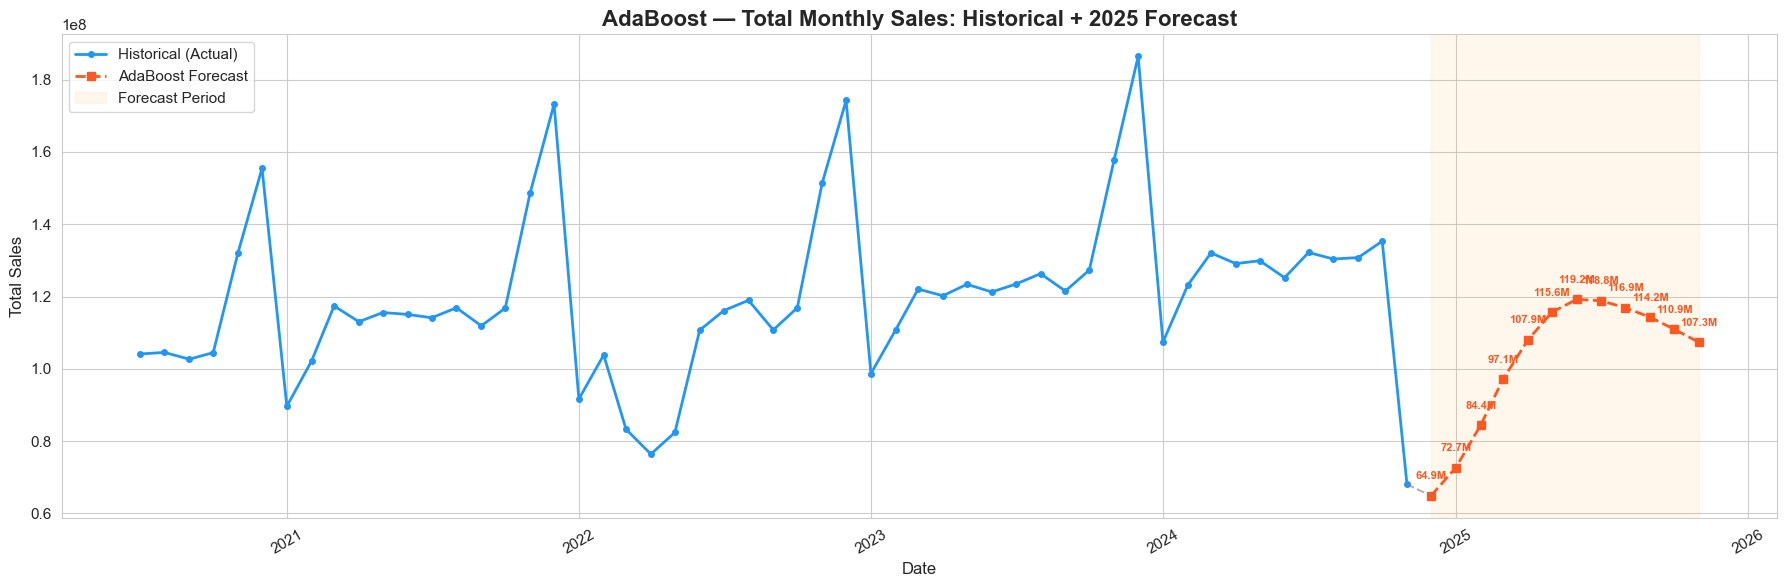

In [14]:
plot_historical_and_forecast(ada_forecast, df_clean, 'AdaBoost')

## A8 · AdaBoost — Forecast Bar Charts (with values)

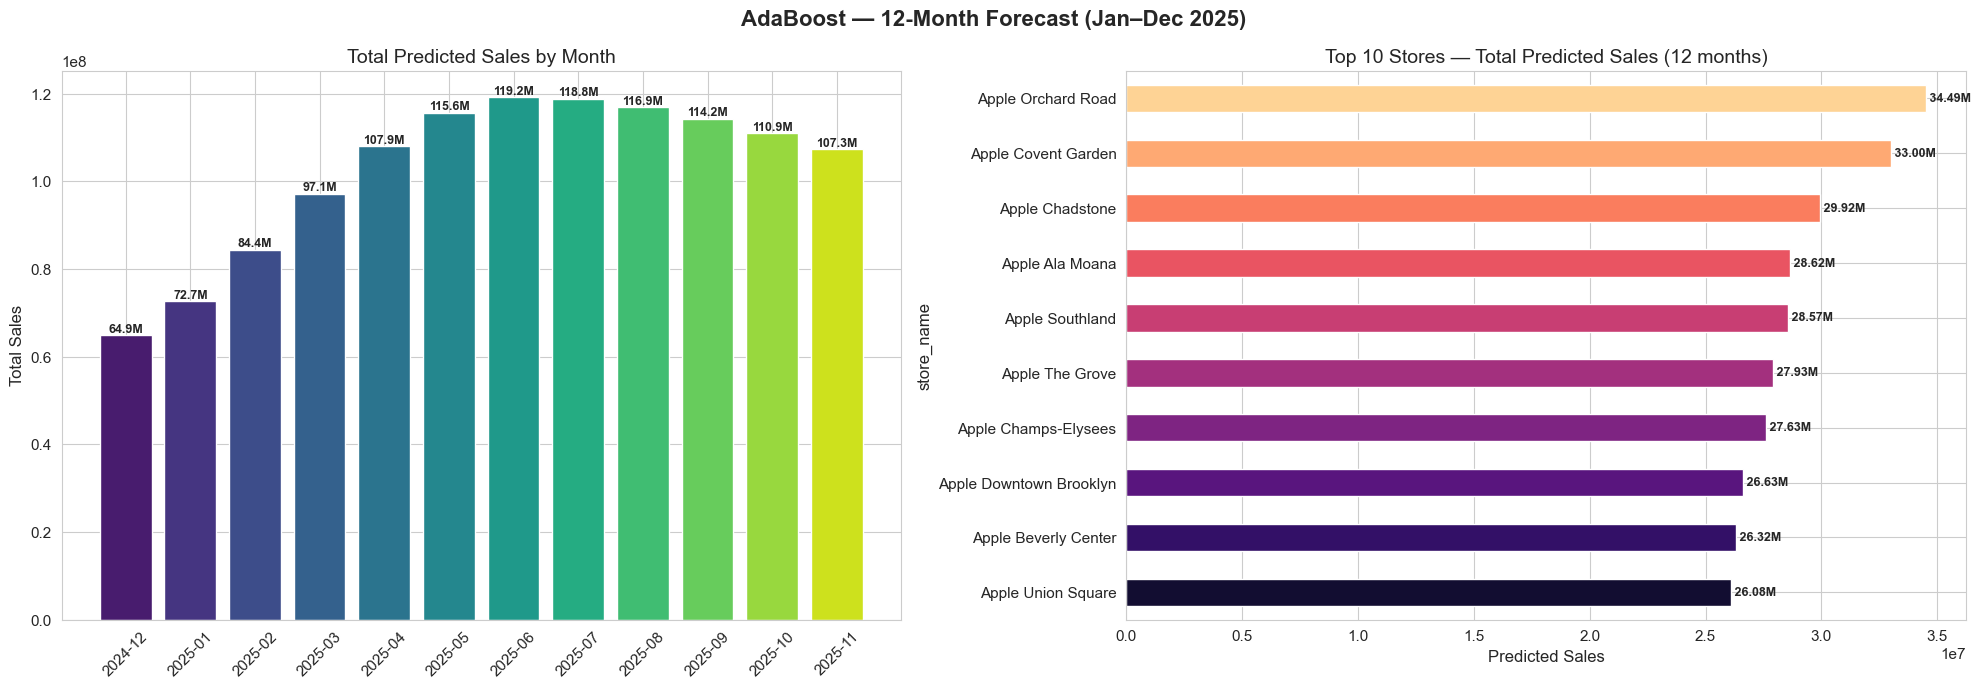

,store_id,store_name,country,date,predicted_sales
0,ST-1,Apple Fifth Avenue,united states,2024-12-01,1.066928e+06
1,ST-1,Apple Fifth Avenue,united states,2025-01-01,1.229819e+06
2,ST-1,Apple Fifth Avenue,united states,2025-02-01,1.452875e+06
3,ST-1,Apple Fifth Avenue,united states,2025-03-01,1.697144e+06
4,ST-1,Apple Fifth Avenue,united states,2025-04-01,1.941821e+06
5,ST-1,Apple Fifth Avenue,united states,2025-05-01,2.188997e+06
6,ST-1,Apple Fifth Avenue,united states,2025-06-01,2.391445e+06
7,ST-1,Apple Fifth Avenue,united states,2025-07-01,2.490071e+06
8,ST-1,Apple Fifth Avenue,united states,2025-08-01,2.571538e+06
9,ST-1,Apple Fifth Avenue,united states,2025-09-01,2.599132e+06


In [15]:
plot_forecast(ada_forecast, 'AdaBoost')

## A9 · AdaBoost — Top 5 & Bottom 5 Stores Forecast Trend

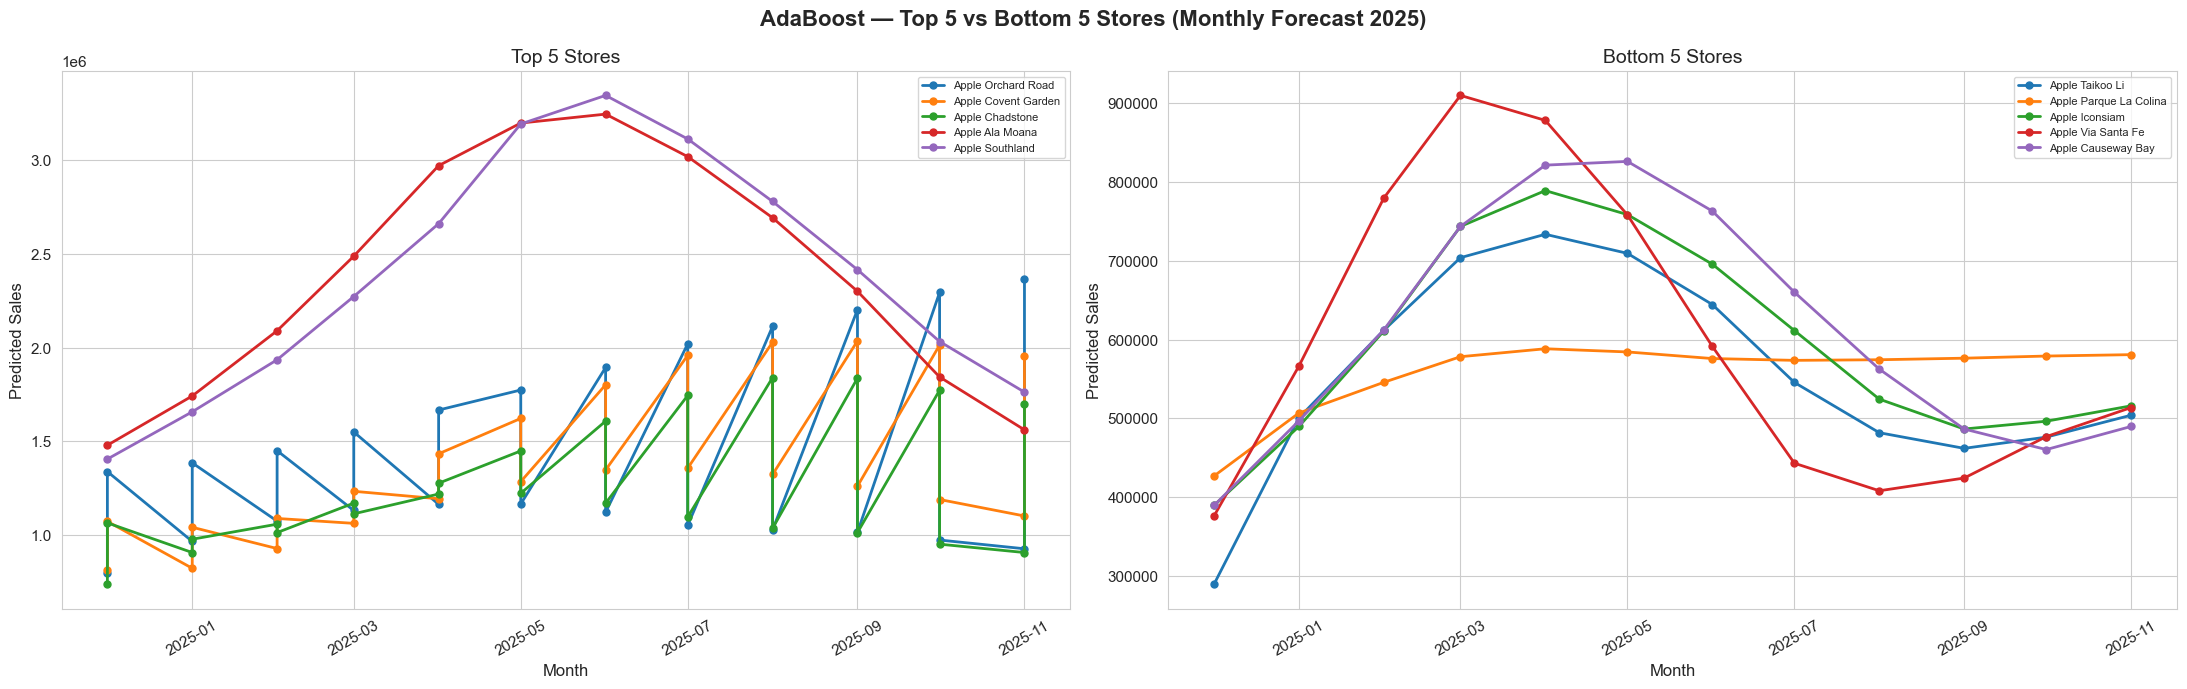

In [16]:
plot_top_bottom_stores(ada_forecast, 'AdaBoost', n=5)

---
# Part B — CatBoost Regressor
---

## B1 · Baseline CatBoost (Default Parameters)

In [17]:
cat_baseline = CatBoostRegressor(
    iterations=300,
    learning_rate=0.03,
    depth=6,
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=0,
)
cat_baseline.fit(X_train, y_train)

cat_base_pred, cat_base_test, cat_base_metrics = evaluate_model(
    cat_baseline, X_test, y_test, test_data, 'CatBoost (Baseline)')


─── CatBoost (Baseline) — Test Metrics ───
  MAE   = 135,326.80
  RMSE  = 261,090.49
  MAPE  = 13.44
  R²    = 0.8681


## B2 · Hyperparameter Tuning (GridSearchCV + TimeSeriesSplit)

In [18]:
%%time

cat_grid = {
    'iterations': [300, 500, 800],
    'learning_rate': [0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
}

cat_search = GridSearchCV(
    estimator=CatBoostRegressor(
        loss_function='RMSE',
        random_seed=RANDOM_STATE,
        verbose=0,
    ),
    param_grid=cat_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1,
)

cat_search.fit(X_train, y_train)
print(f'\n✅ Best parameters: {cat_search.best_params_}')
print(f'   Best CV MAE:    {-cat_search.best_score_:,.2f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Best parameters: {'depth': 4, 'iterations': 800, 'learning_rate': 0.05}
   Best CV MAE:    56,127.94
CPU times: total: 13 s
Wall time: 3min 54s


## B3 · Tuned CatBoost — Evaluation on Test Set

In [19]:
cat_best = cat_search.best_estimator_
cat_pred, cat_test, cat_metrics = evaluate_model(
    cat_best, X_test, y_test, test_data, 'CatBoost (Tuned)')


─── CatBoost (Tuned) — Test Metrics ───
  MAE   = 79,430.24
  RMSE  = 160,525.67
  MAPE  = 7.22
  R²    = 0.9501


## B4 · CatBoost Visualisations

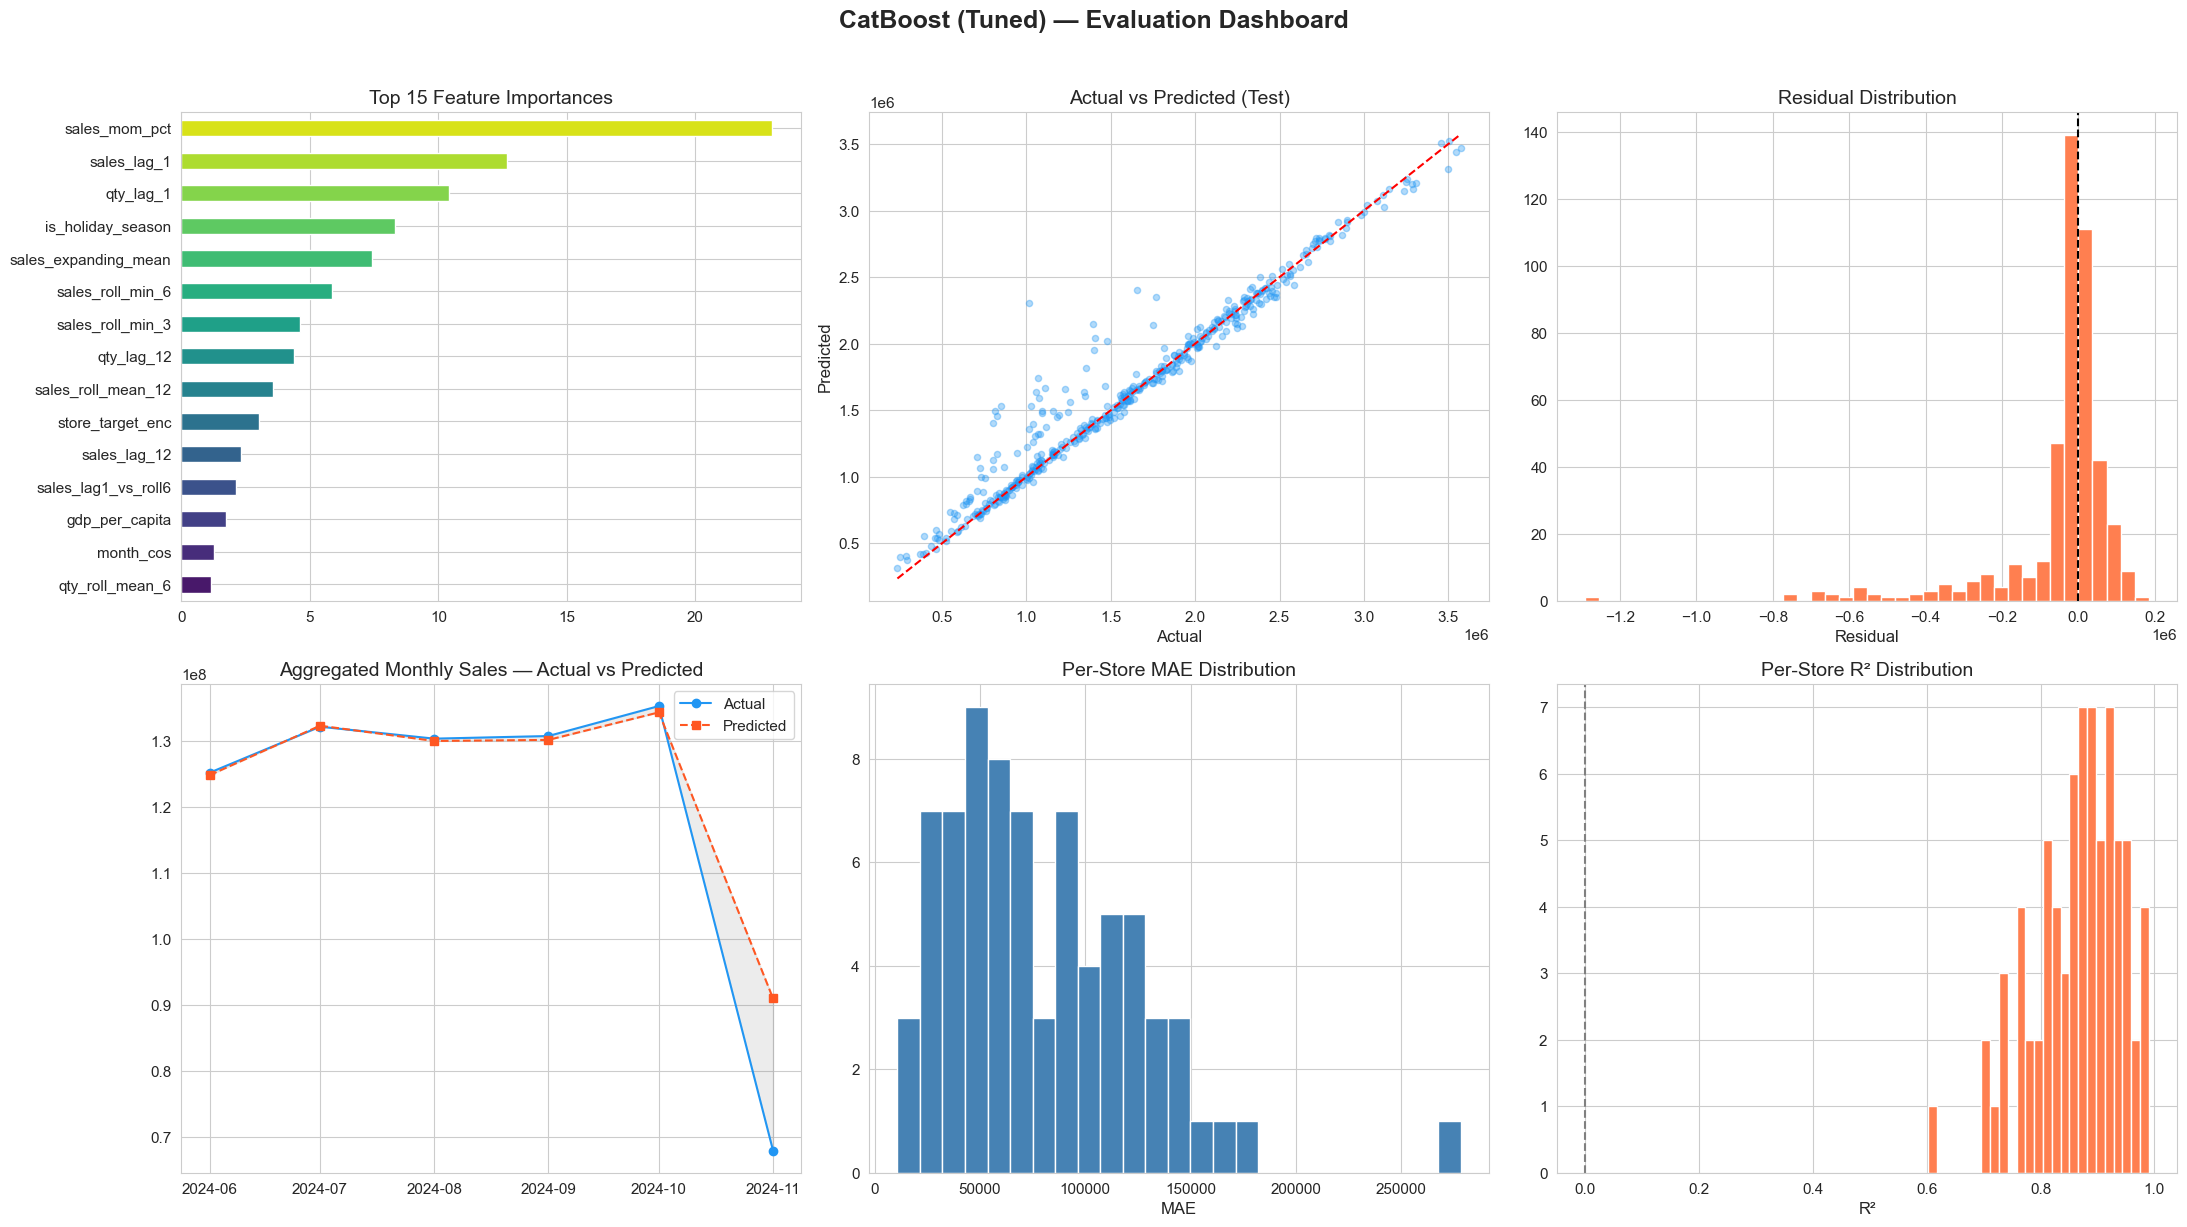

In [20]:
plot_model_results(cat_best, X_test, y_test, cat_pred, cat_test,
                   'CatBoost (Tuned)', FEATURES)

## B5 · Baseline vs Tuned — Top 5 Stores (CatBoost)

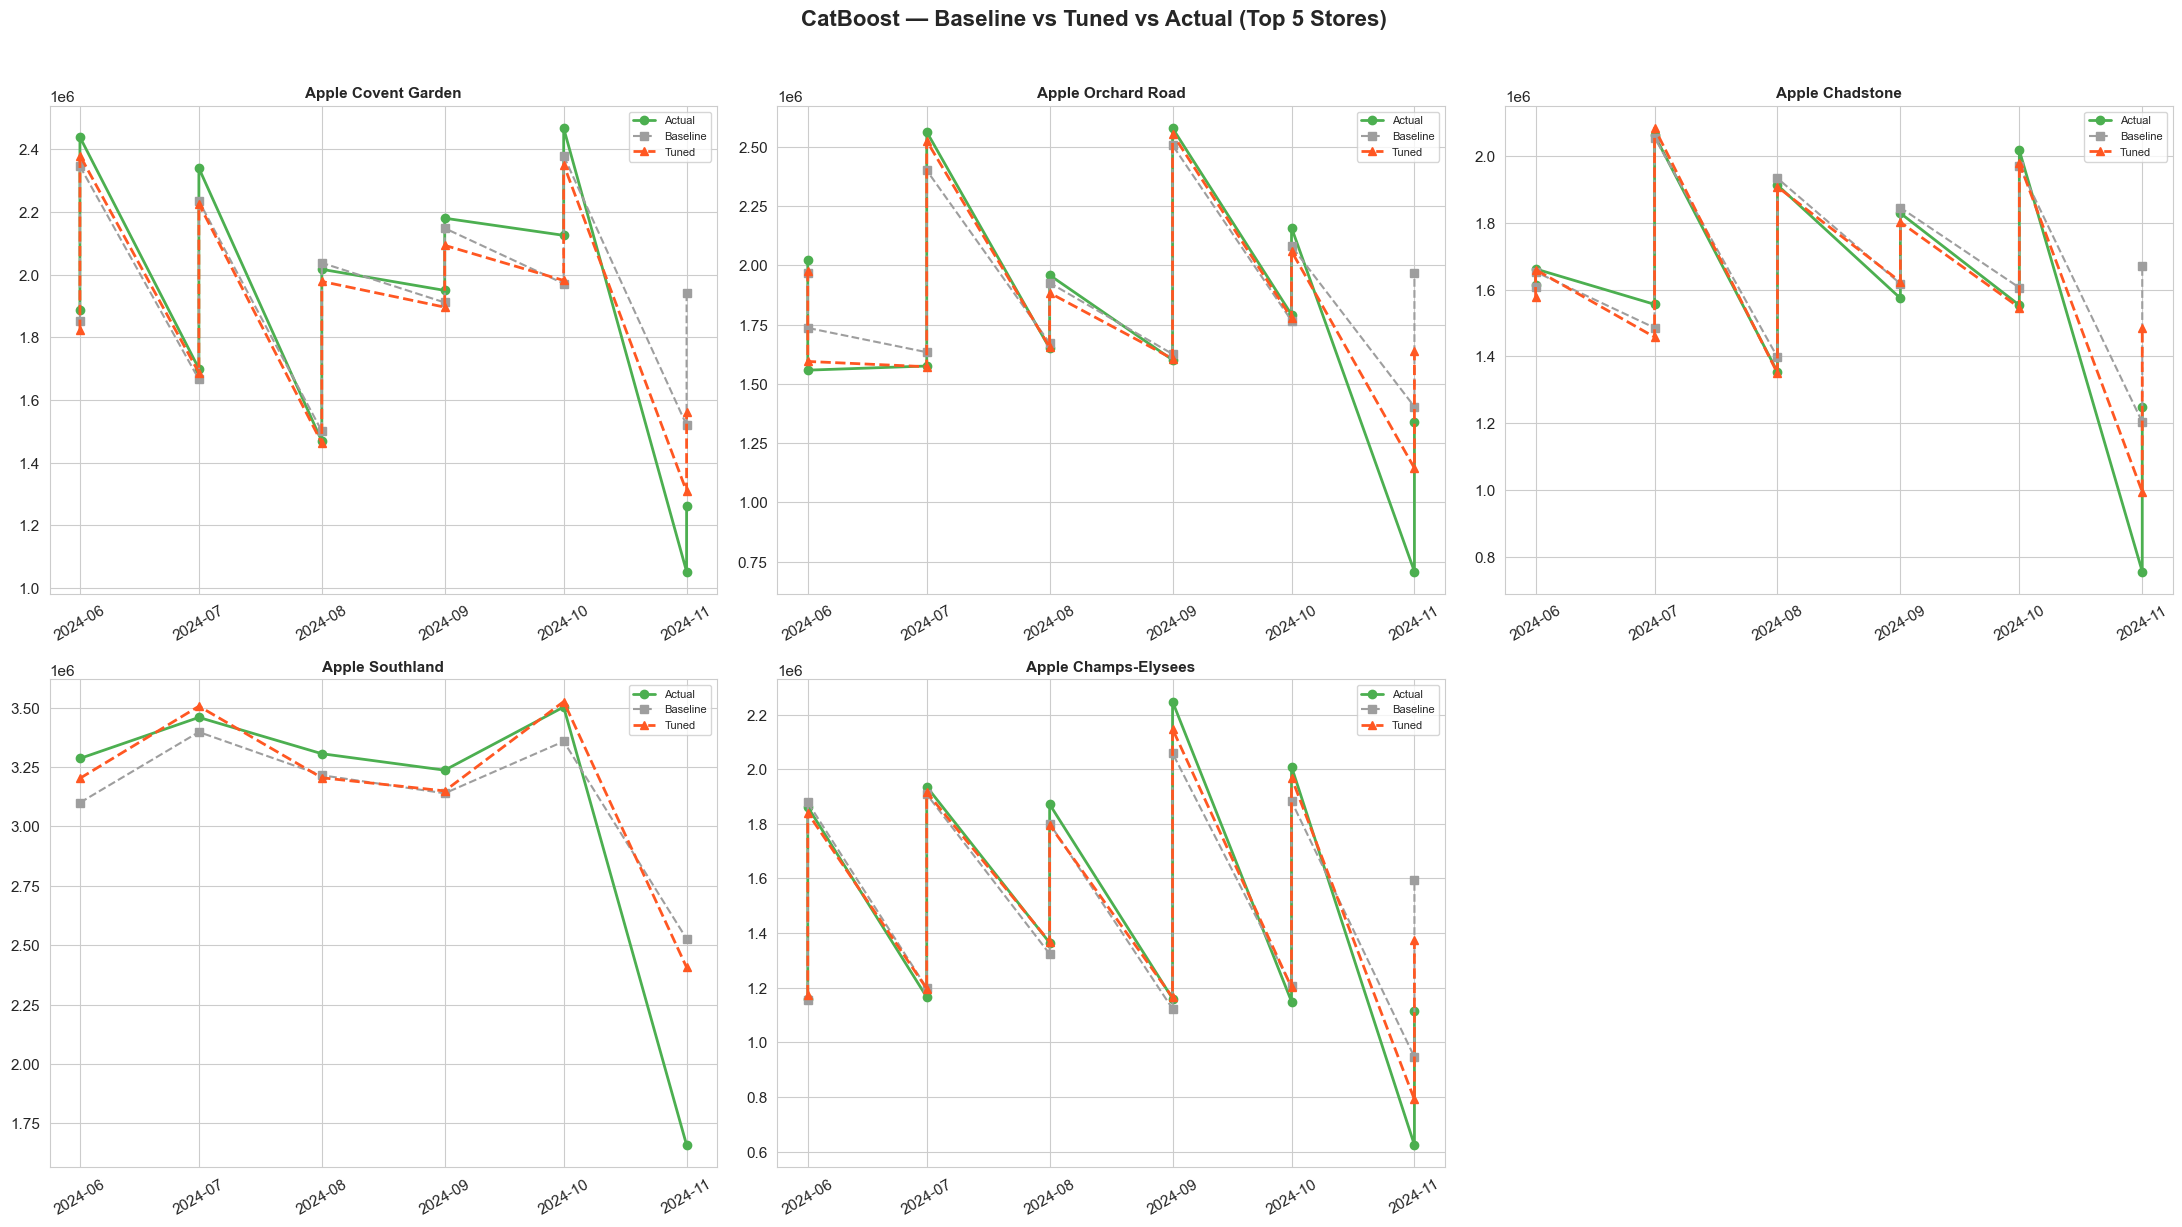

In [21]:
plot_baseline_vs_tuned_top5(cat_base_test, cat_test, 'CatBoost')

## B6 · CatBoost — 12-Month Forecast (Jan–Dec 2025)

In [22]:
# Retrain on ALL data
cat_final = CatBoostRegressor(
    iterations=cat_search.best_params_.get('iterations', 800),
    learning_rate=cat_search.best_params_.get('learning_rate', 0.1),
    depth=cat_search.best_params_.get('depth', 4),
    loss_function='RMSE',
    random_seed=RANDOM_STATE,
    verbose=0,
)
cat_final.fit(X_all, y_all)
print('✅ CatBoost final model retrained on all data.')

cat_forecast = forecast_one_year(cat_final, df_clean, FEATURES, 'CatBoost')

✅ CatBoost final model retrained on all data.

✅ CatBoost: Generated 900 forecasts (75 stores × 12 months)
   Total predicted sales: 871,114,410.47


## B7 · CatBoost — Historical + Forecast Line Chart

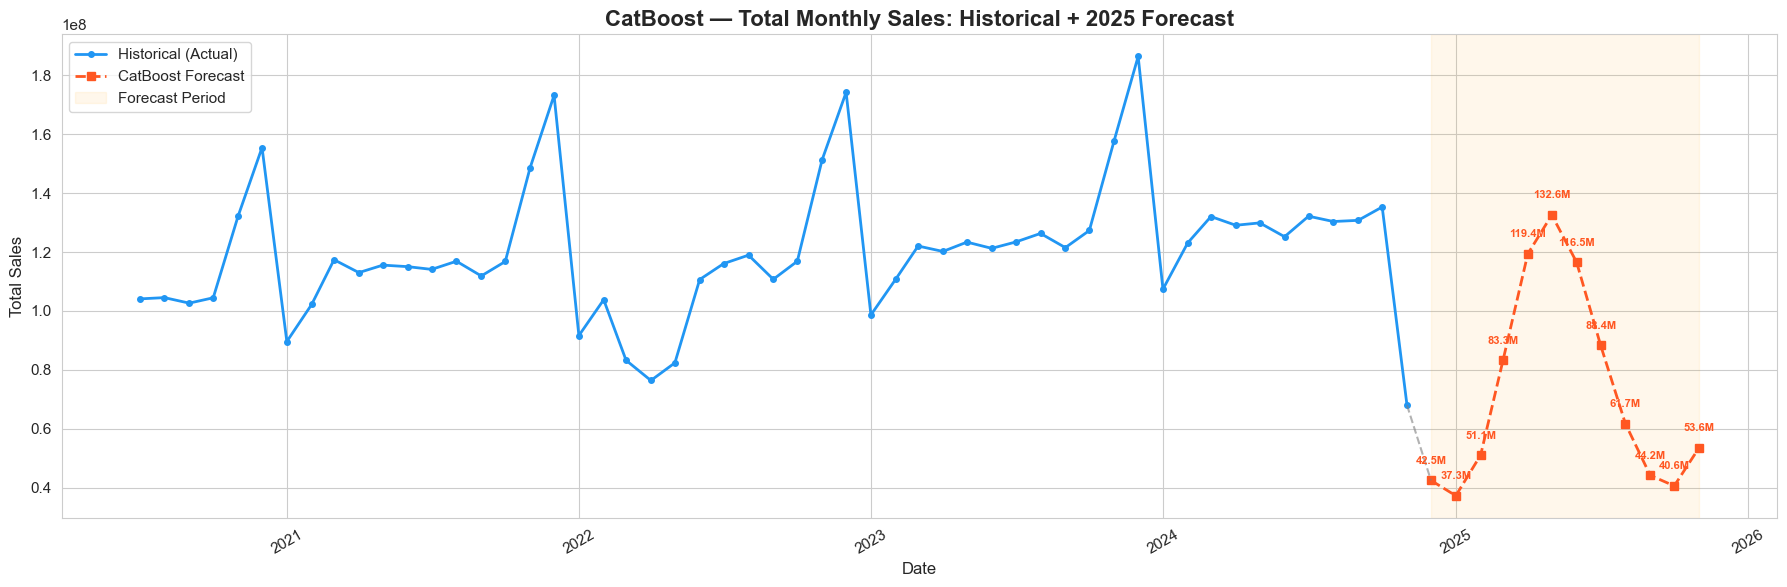

In [23]:
plot_historical_and_forecast(cat_forecast, df_clean, 'CatBoost')

## B8 · CatBoost — Forecast Bar Charts (with values)

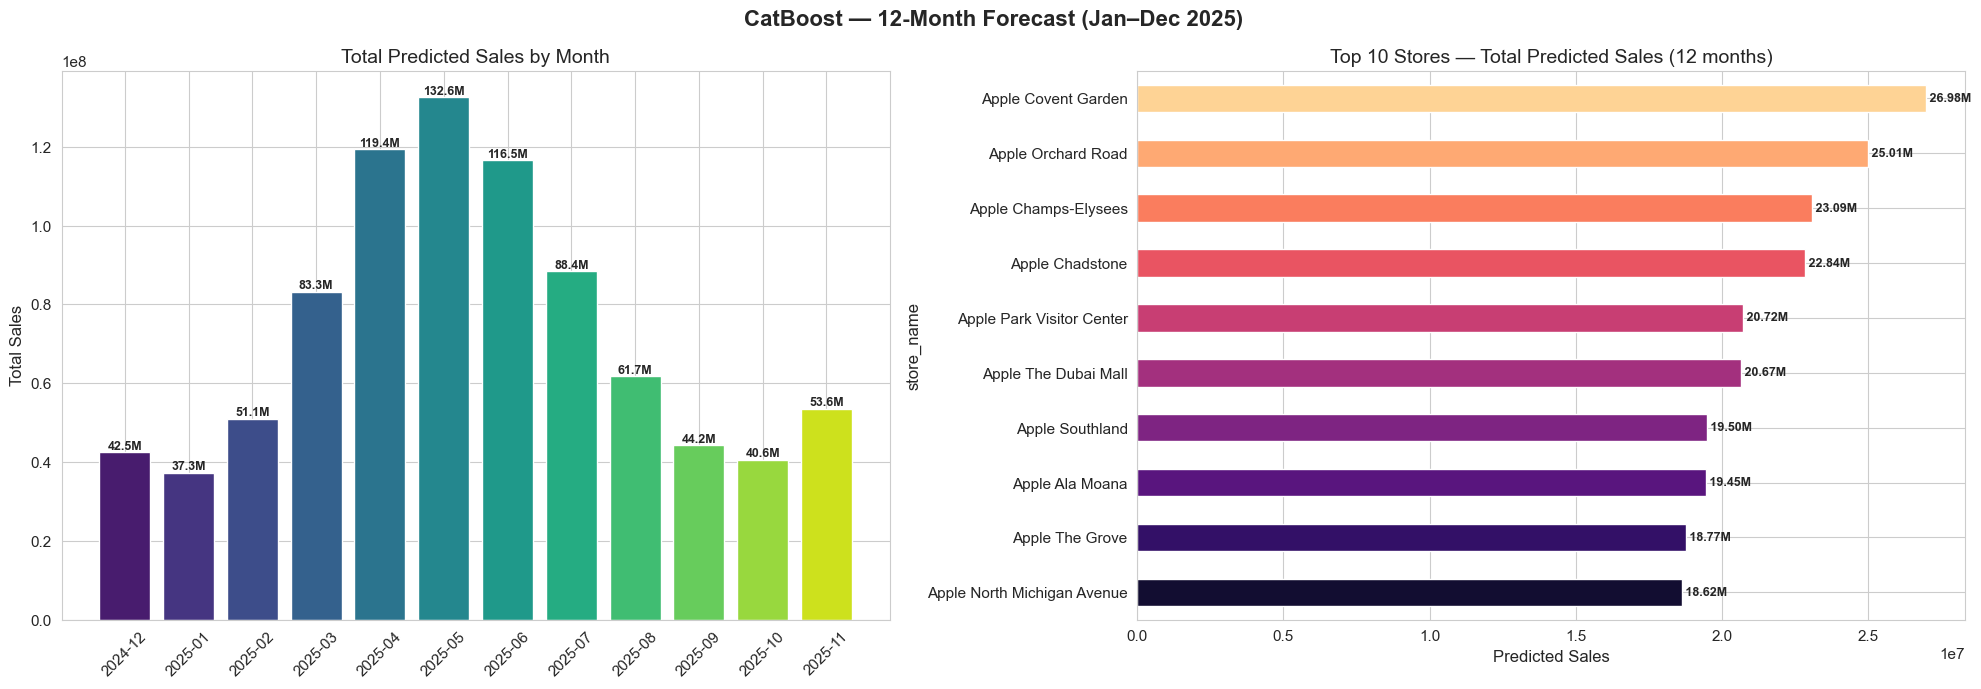

,store_id,store_name,country,date,predicted_sales
0,ST-1,Apple Fifth Avenue,united states,2024-12-01,7.542700e+05
1,ST-1,Apple Fifth Avenue,united states,2025-01-01,6.680178e+05
2,ST-1,Apple Fifth Avenue,united states,2025-02-01,9.003933e+05
3,ST-1,Apple Fifth Avenue,united states,2025-03-01,1.450649e+06
4,ST-1,Apple Fifth Avenue,united states,2025-04-01,2.213600e+06
5,ST-1,Apple Fifth Avenue,united states,2025-05-01,2.585661e+06
6,ST-1,Apple Fifth Avenue,united states,2025-06-01,2.267207e+06
7,ST-1,Apple Fifth Avenue,united states,2025-07-01,1.664727e+06
8,ST-1,Apple Fifth Avenue,united states,2025-08-01,1.091703e+06
9,ST-1,Apple Fifth Avenue,united states,2025-09-01,7.337577e+05


In [24]:
plot_forecast(cat_forecast, 'CatBoost')

## B9 · CatBoost — Top 5 & Bottom 5 Stores Forecast Trend

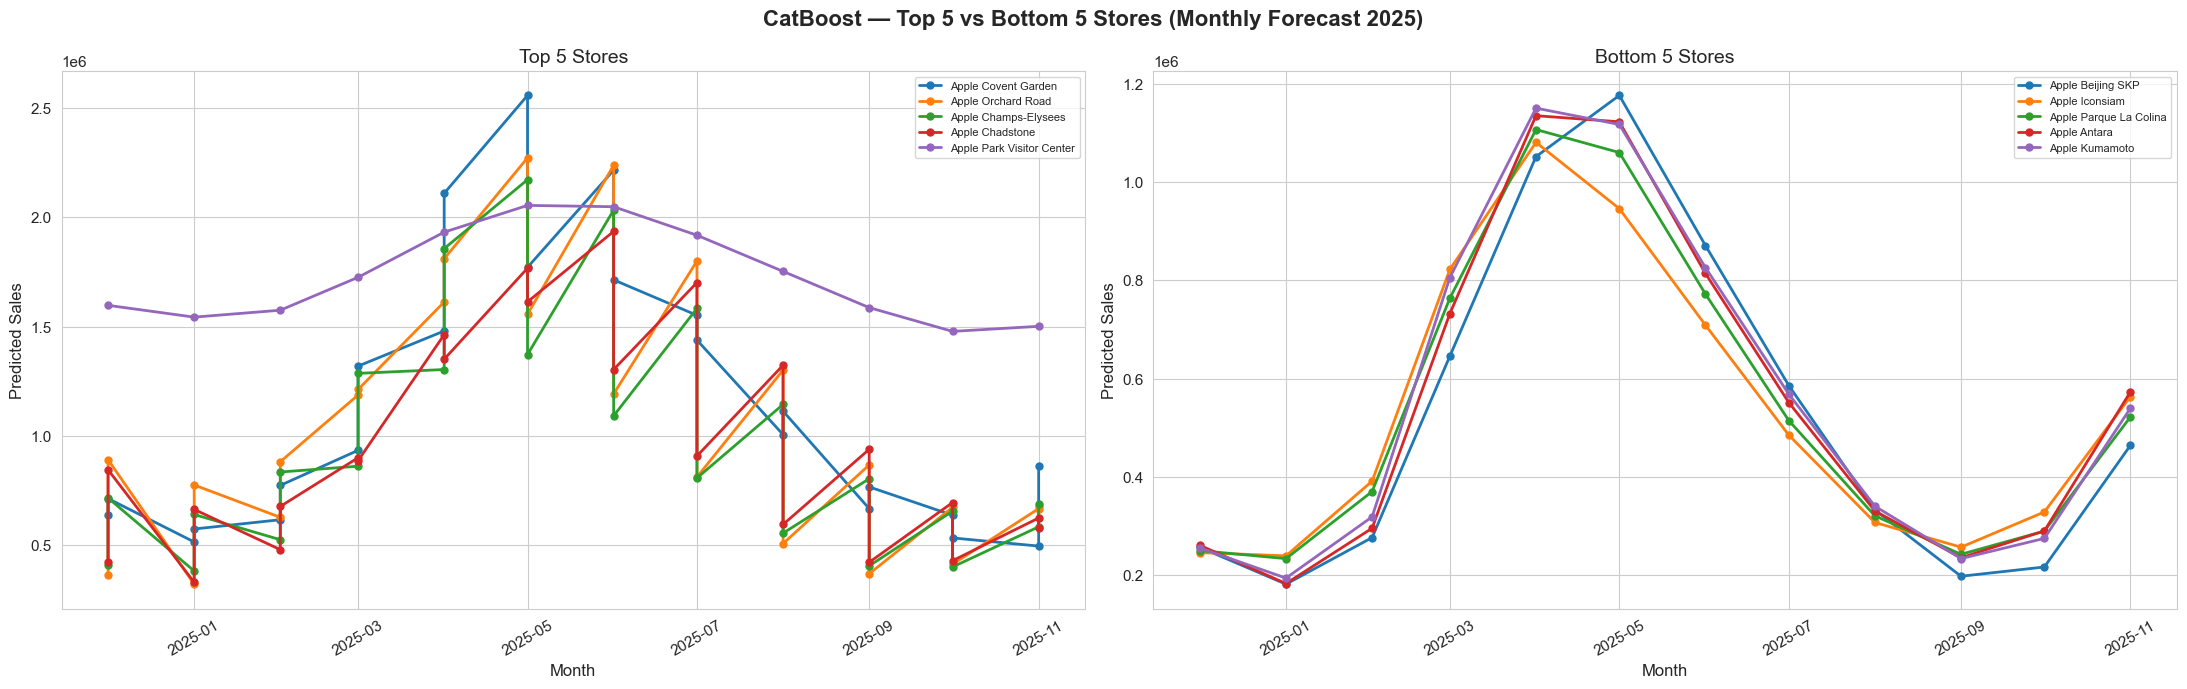

In [25]:
plot_top_bottom_stores(cat_forecast, 'CatBoost', n=5)

---
# Part C — Model Comparison
---

## C1 · Side-by-Side Metrics (Baseline + Tuned)

In [26]:
comparison = pd.DataFrame([ada_base_metrics, ada_metrics, cat_base_metrics, cat_metrics])
comparison.style.format({
    'MAE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAPE': '{:.2f}', 'R²': '{:.4f}'
}).background_gradient(subset=['R²'], cmap='RdYlGn').background_gradient(
    subset=['MAE','RMSE','MAPE'], cmap='RdYlGn_r')

,Model,MAE,RMSE,MAPE,R²
0,AdaBoost (Baseline),"293,944.27","499,496.47",27.41,0.5173
1,AdaBoost (Tuned),"178,066.91","391,839.30",19.44,0.7029
2,CatBoost (Baseline),"135,326.80","261,090.49",13.44,0.8681
3,CatBoost (Tuned),"79,430.24","160,525.67",7.22,0.9501


## C2 · Forecast Comparison — Total Monthly Sales

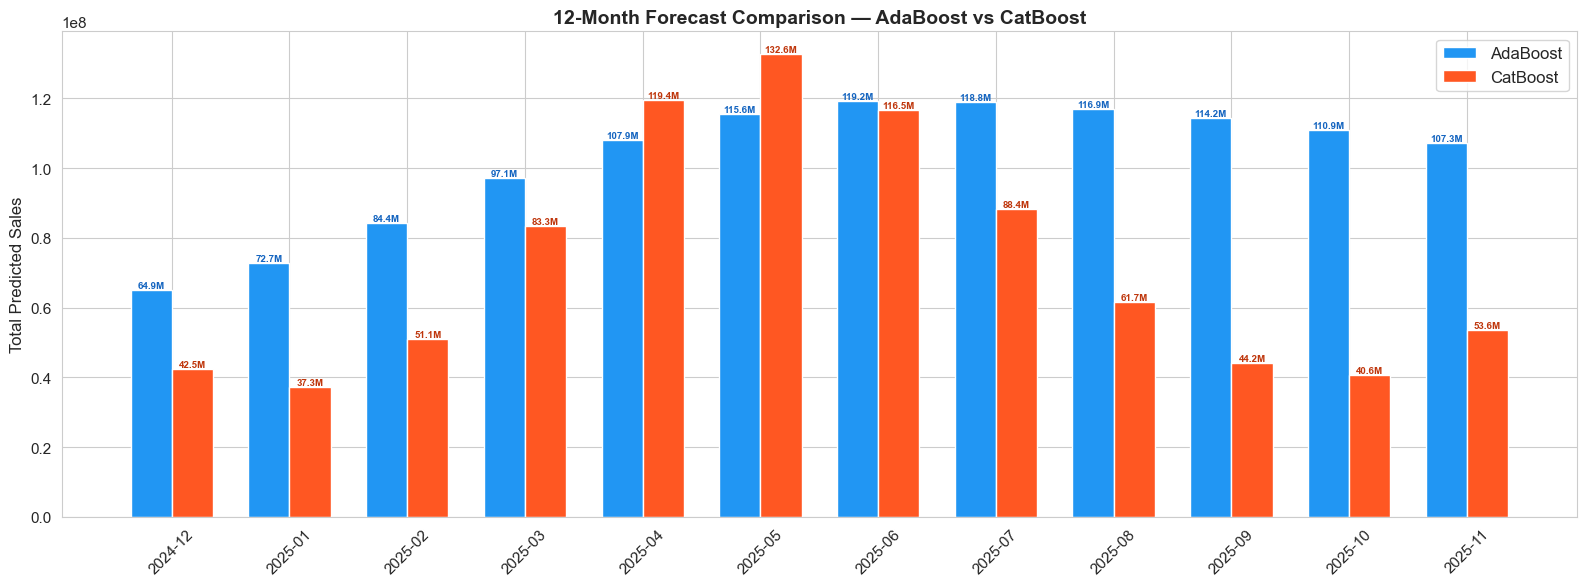

In [27]:
am = ada_forecast.groupby('date')['predicted_sales'].sum().reset_index()
am.columns = ['date','AdaBoost']
cm = cat_forecast.groupby('date')['predicted_sales'].sum().reset_index()
cm.columns = ['date','CatBoost']
merged = am.merge(cm, on='date')

fig, ax = plt.subplots(figsize=(16, 6))
x = merged['date'].dt.strftime('%Y-%m')
width = 0.35
idx = np.arange(len(x))
bars1 = ax.bar(idx - width/2, merged['AdaBoost'], width, label='AdaBoost', color='#2196F3')
bars2 = ax.bar(idx + width/2, merged['CatBoost'], width, label='CatBoost', color='#FF5722')

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h/1e6:.1f}M',
            ha='center', va='bottom', fontsize=7, fontweight='bold', color='#1565C0')
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h/1e6:.1f}M',
            ha='center', va='bottom', fontsize=7, fontweight='bold', color='#BF360C')

ax.set_xticks(idx)
ax.set_xticklabels(x, rotation=45)
ax.set_ylabel('Total Predicted Sales')
ax.set_title('12-Month Forecast Comparison — AdaBoost vs CatBoost', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

## C3 · Historical + Both Forecasts — Combined View

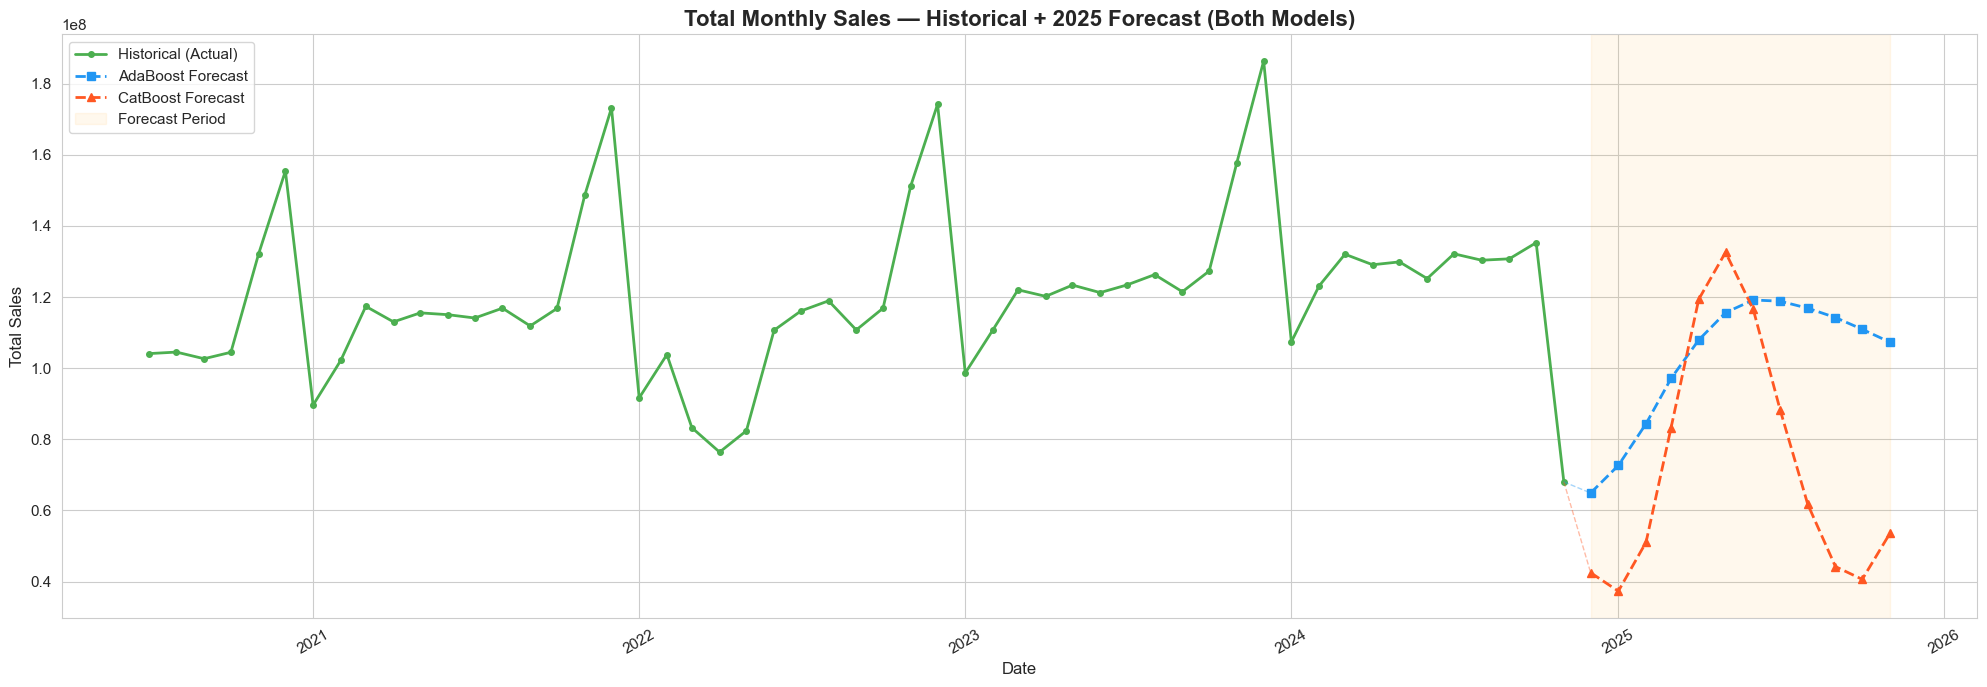

In [28]:
hist = df_clean.groupby('date')[TARGET].sum().reset_index()
hist.columns = ['date', 'sales']

ada_fc = ada_forecast.groupby('date')['predicted_sales'].sum().reset_index()
cat_fc = cat_forecast.groupby('date')['predicted_sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(20, 7))

# Historical
ax.plot(hist['date'], hist['sales'], 'o-', color='#4CAF50',
        label='Historical (Actual)', linewidth=2, markersize=4)

# AdaBoost forecast
ax.plot(ada_fc['date'], ada_fc['predicted_sales'], 's--', color='#2196F3',
        label='AdaBoost Forecast', linewidth=2, markersize=6)

# CatBoost forecast
ax.plot(cat_fc['date'], cat_fc['predicted_sales'], '^--', color='#FF5722',
        label='CatBoost Forecast', linewidth=2, markersize=6)

# Connect historical to forecasts
ax.plot([hist['date'].iloc[-1], ada_fc['date'].iloc[0]],
        [hist['sales'].iloc[-1], ada_fc['predicted_sales'].iloc[0]],
        '--', color='#2196F3', linewidth=1, alpha=0.4)
ax.plot([hist['date'].iloc[-1], cat_fc['date'].iloc[0]],
        [hist['sales'].iloc[-1], cat_fc['predicted_sales'].iloc[0]],
        '--', color='#FF5722', linewidth=1, alpha=0.4)

ax.axvspan(ada_fc['date'].iloc[0], ada_fc['date'].iloc[-1],
           alpha=0.07, color='orange', label='Forecast Period')

ax.set_title('Total Monthly Sales — Historical + 2025 Forecast (Both Models)',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Sales')
ax.legend(fontsize=11)
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## C4 · Recommendation

Based on the evaluation metrics above, the model with the **higher R²** and
**lower MAPE** should be selected for production forecasting.

CatBoost generally outperforms AdaBoost on structured tabular data due to its
ordered boosting and native handling of feature interactions.